# Analysing District Counts Across Indian States and Union Territories

In [1]:
import fiona
import geopandas as gpd
import matplotlib.pyplot as plt
import colorcet as cc
from adjustText import adjust_text

## Inspecting the Indian States and Union Territories GeoDataFrame

In [2]:
!ls ../../data

india_admin_areas.geojson   nederland_pop_centres.gpkg	 sources
nederland_admin_areas.gpkg  nederland_pop_stats.feather


In [3]:
data_folder = '../../data'

In [4]:
states = gpd.read_file(f'{data_folder}/india_admin_areas.geojson')
states.shape

(759, 7)

In [5]:
states.head(1)

,id,district,dt_code,st_nm,st_code,year,geometry
0,None,Aizawl,261,Mizoram,15,2011_c,"POLYGON ((93.04466 23.41052, 92.9468 23.51363,..."


In [6]:
states = states.dissolve(by='st_nm', as_index=False)
states.shape

(36, 7)

In [7]:
print(states.crs)

EPSG:4326


In [8]:
states = states.to_crs('EPSG:7755')
states.head(1)

,st_nm,geometry,id,district,dt_code,st_code,year
0,Andaman and Nicobar Islands,"MULTIPOLYGON (((5421372.105 2445285.006, 54260...",Andaman and Nicobar Islands,North and Middle Andaman,639,35,2011_c


## Visualising the States and Union Territories

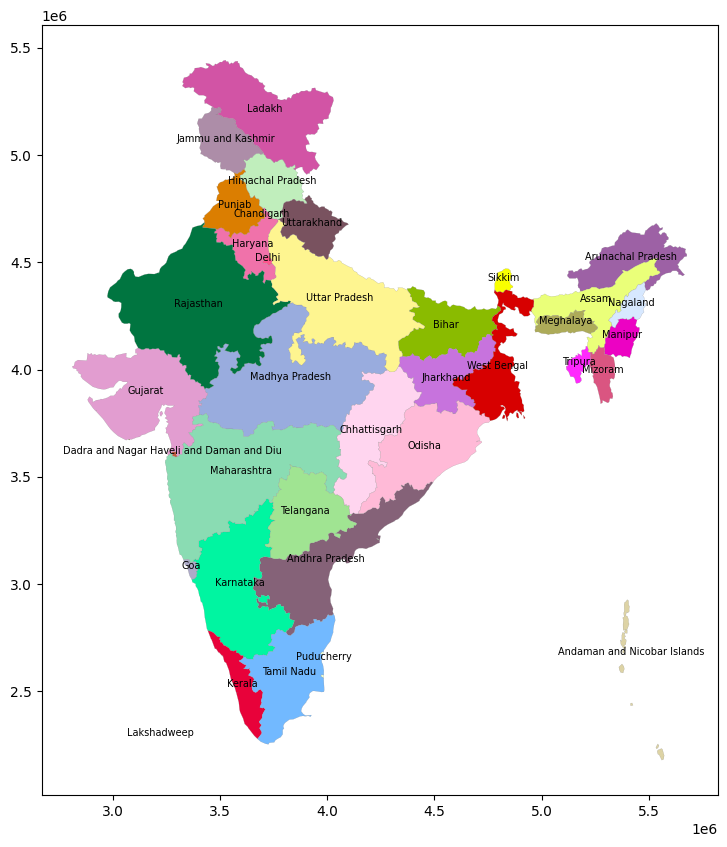

In [9]:
fig, ax = plt.subplots(figsize=(10,10))
states.plot(ax=ax, column='st_nm', cmap=cc.cm.glasbey_light_r, edgecolor='grey', linewidth=0.125)

for row in states.itertuples():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    if row.st_nm in ['Chandigarh', 'Jharkhand']:
        y-= 0.25 * 10**5
    
    ax.annotate(xy=(x,y), text=row.st_nm, ha='center', fontsize=7)

plt.show()

## Inspecting the Districts GeoDataFrame

In [10]:
districts = gpd.read_file(f'{data_folder}/india_admin_areas.geojson')
districts.shape

(759, 7)

In [11]:
print(districts.crs)

EPSG:4326


In [12]:
districts = districts.to_crs('EPSG:7755')
districts.head(1)

,id,district,dt_code,st_nm,st_code,year,geometry
0,None,Aizawl,261,Mizoram,15,2011_c,"POLYGON ((5305539.779 3996462.607, 5294745.141..."


## Visualising the Districts

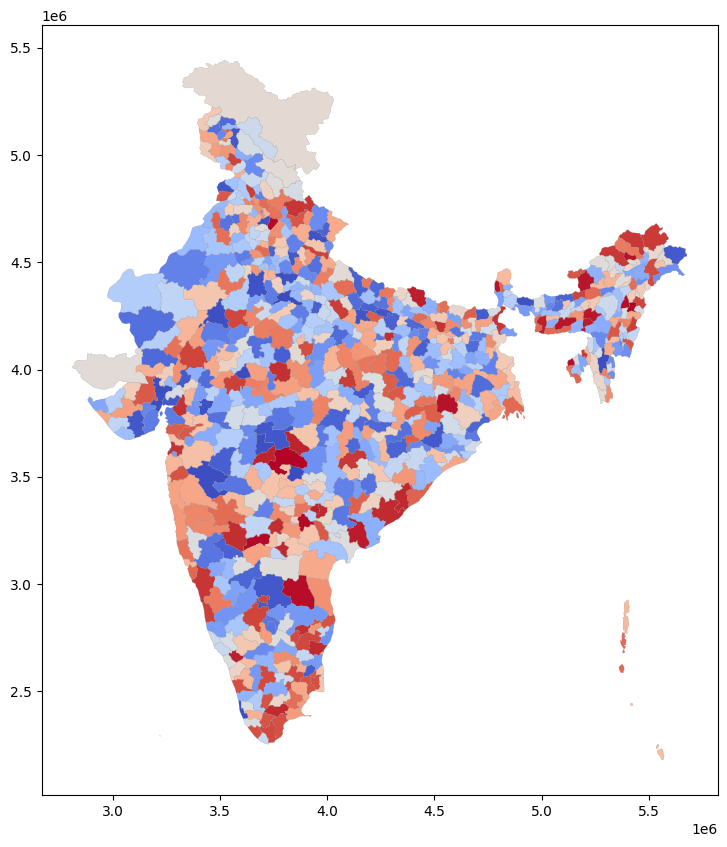

In [13]:
fig, ax = plt.subplots(figsize=(10,10))
districts.plot(ax=ax, column='district', cmap='coolwarm', edgecolor='grey', linewidth=0.125)

plt.show()

## Spatial Join: Within

In [14]:
joined_gdf = districts.sjoin(states, how='left', predicate='within')
joined_gdf.shape

(759, 14)

In [15]:
joined_gdf.head(1)

,id_left,district_left,dt_code_left,st_nm_left,st_code_left,year_left,geometry,index_right,st_nm_right,id_right,district_right,dt_code_right,st_code_right,year_right
0,None,Aizawl,261,Mizoram,15,2011_c,"POLYGON ((5305539.779 3996462.607, 5294745.141...",23,Mizoram,Mizoram,Aizawl,261,15,2011_c


In [16]:
grouped_gdf = joined_gdf.groupby('st_nm_left')
len(grouped_gdf)

36

In [17]:
district_count = grouped_gdf['st_nm_right'].count().reset_index()
district_count['st_nm_right'].sum()

np.int64(759)

In [18]:
states = states.merge(district_count, how='left', left_on='st_nm', right_on='st_nm_left')
states.head(1)

,st_nm,geometry,id,district,dt_code,st_code,year,st_nm_left,st_nm_right
0,Andaman and Nicobar Islands,"MULTIPOLYGON (((5421372.105 2445285.006, 54260...",Andaman and Nicobar Islands,North and Middle Andaman,639,35,2011_c,Andaman and Nicobar Islands,4


## GeoDataFrame Cleaning

In [19]:
states = states[['st_nm', 'st_nm_right', 'geometry']]
states = states.rename(columns={'st_nm': 'name', 'st_nm_right': 'district_count'})

states.head(1)

,name,district_count,geometry
0,Andaman and Nicobar Islands,4,"MULTIPOLYGON (((5421372.105 2445285.006, 54260..."


## Visualising the Final Results
### Bar Chart

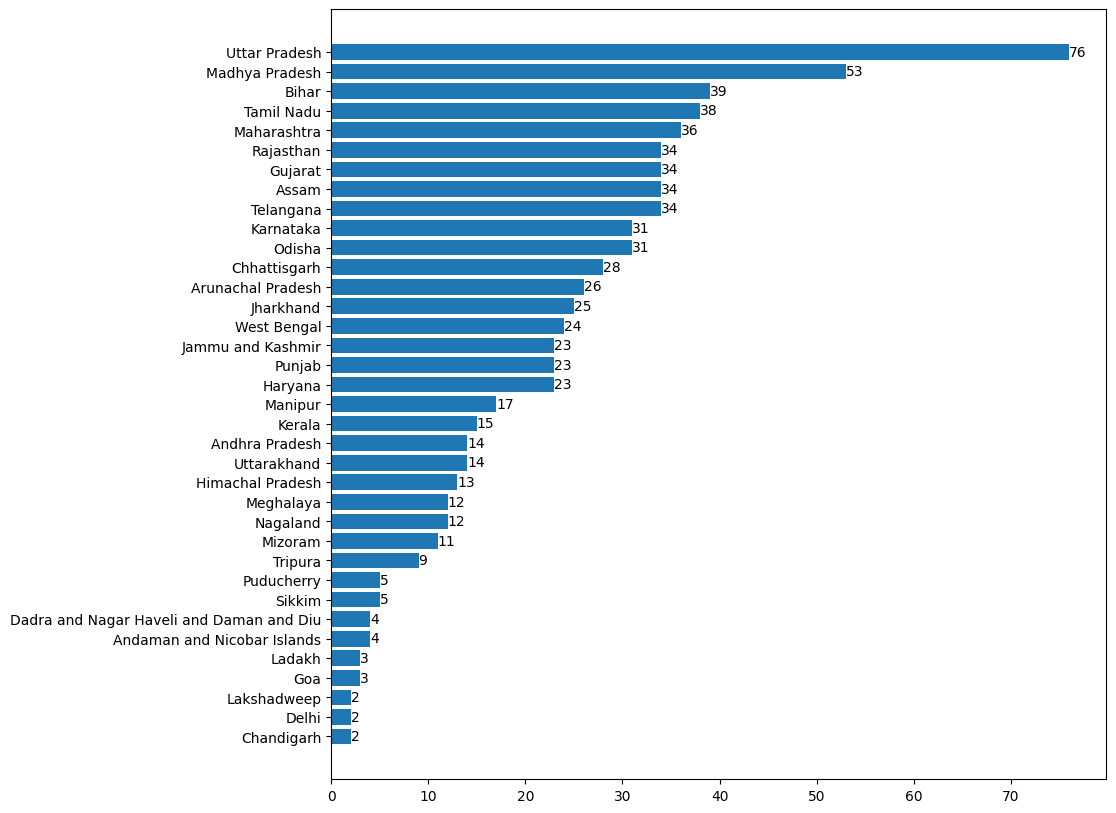

In [20]:
sorted_states = states.sort_values(by='district_count', ascending=True)

fig, ax = plt.subplots(figsize=(10,10))
bars = ax.barh(sorted_states['name'], sorted_states['district_count'])

ax.bar_label(bars, sorted_states['district_count'])
ax.tick_params(axis='y', labelsize=10)

plt.show()

### Map

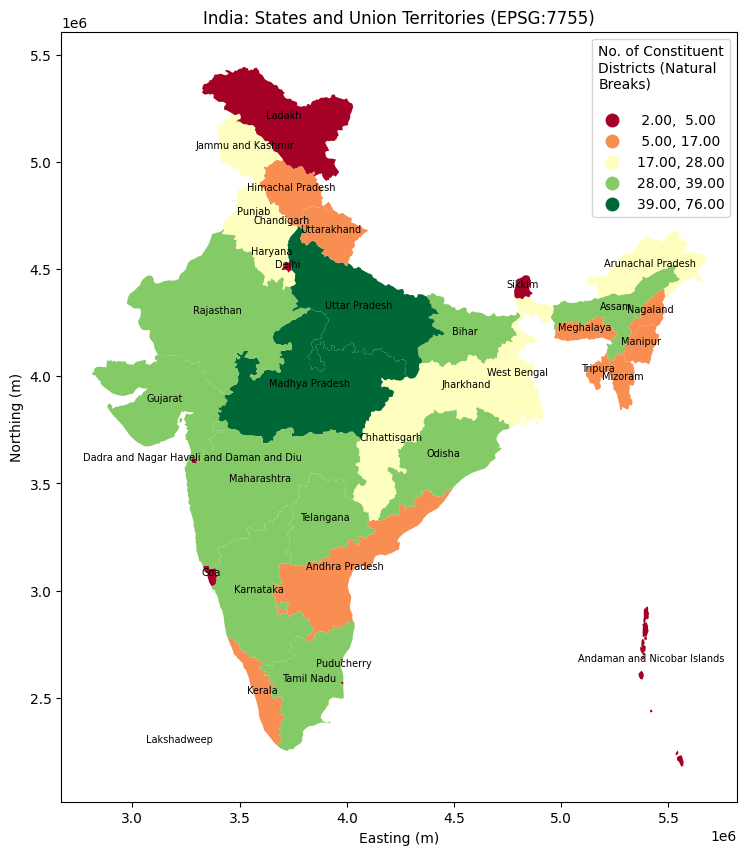

In [21]:
fig, ax = plt.subplots(figsize=(10,10))
states.plot(
    ax=ax,
    column='district_count',
    scheme='naturalbreaks',
    k=5,
    cmap='RdYlGn',
    legend=True,
    legend_kwds={
        'title': 'No. of Constituent\nDistricts (Natural\nBreaks)\n',
    }
)

for row in states.itertuples():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    if row.name in ['Chandigarh', 'Jharkhand']:
        y -= 0.25 * 10**5

    ax.annotate(xy=(x,y), text=row.name, ha='center', fontsize=7)

ax.set_title('India: States and Union Territories (EPSG:7755)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

plt.show()

In [22]:
alt = gpd.read_file(f'{data_folder}/india_admin_areas.geojson')
alt = alt[alt['st_nm']=='Uttar Pradesh']
for i in alt['district']:
    print(i)

Amroha
Hapur
Bareilly
Pilibhit
Bulandshahr
Gautam Buddha Nagar
Lakhimpur Kheri
Budaun
Bahraich
Shahjahanpur
Aligarh
Kasganj
Mathura
Shrawasti
Sitapur
Hathras
Etah
Hardoi
Farrukhabad
Firozabad
Siddharthnagar
Mainpuri
Maharajganj
Agra
Gonda
Barabanki
Kushinagar
Kannauj
Lucknow
Basti
Gorakhpur
Sant Kabir Nagar
Unnao
Etawah
Kanpur Nagar
Auraiya
Ayodhya
Kanpur Dehat
Deoria
Sultanpur
Ambedkar Nagar
Rae Bareli
Jalaun
Azamgarh
Mau
Fatehpur
Ballia
Jaunpur
Jhansi
Banda
Ghazipur
Kaushambi
Prayagraj
Varanasi
Chitrakoot
Chandauli
Bhadohi
Mirzapur
Lalitpur
Sonbhadra
Amethi
Ghaziabad
Sambhal
Mahoba
Saharanpur
Bijnor
Muzaffarnagar
Baghpat
Meerut
Moradabad
Rampur
Shamli
Balrampur
Hamirpur
Pratapgarh
None
